# S06 - Evaluation Metrics
## Exercises

### Exercise 1 (Easy)
Calculate accuracy, precision, recall, and F1 manually from a confusion matrix.

In [2]:
# Confusion Matrix:
# Predicted:  Pos  Neg
# Actual Pos: 40   10  (TP=40, FN=10)
# Actual Neg:  5   45  (FP=5, TN=45)

TP, FP, FN, TN = 40, 5, 10, 45

# Calculate metrics
accuracy = (TP + TN) / (TP + FP + FN + TN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


Accuracy: 0.85
Precision: 0.89
Recall: 0.80
F1 Score: 0.84


### Exercise 2 (Easy)
Use sklearn to compute these metrics for a classification result.

In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_true = [1, 1, 1, 0, 0, 0, 1, 0, 1, 0]
y_pred = [1, 0, 1, 0, 1, 0, 1, 0, 0, 0]

# Calculate all metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.70
Precision: 0.75
Recall: 0.60
F1 Score: 0.67

Confusion Matrix:
[[4 1]
 [2 3]]


### Exercise 3 (Medium)
Generate and visualize a classification report for a multi-class problem.

In [4]:
from sklearn.metrics import classification_report
import numpy as np

# 3-class problem: 0=negative, 1=neutral, 2=positive
y_true = [0, 0, 1, 1, 2, 2, 0, 1, 2, 0, 1, 2]
y_pred = [0, 1, 1, 1, 2, 1, 0, 0, 2, 0, 1, 2]

# Generate classification report
print(classification_report(y_true, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.75      0.75      0.75         4
     Neutral       0.60      0.75      0.67         4
    Positive       1.00      0.75      0.86         4

    accuracy                           0.75        12
   macro avg       0.78      0.75      0.76        12
weighted avg       0.78      0.75      0.76        12



### Exercise 4 (Medium)
Plot a ROC curve and calculate AUC for a binary classifier.

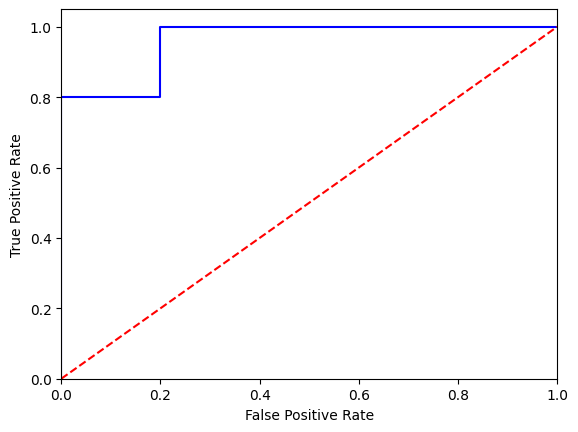

In [7]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predicted probabilities (not class labels)
y_true = [0, 0, 1, 1, 0, 1, 0, 1, 1, 0]
y_scores = [0.1, 0.4, 0.35, 0.8, 0.2, 0.9, 0.3, 0.6, 0.7, 0.25]

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores) # Calculate False Positive Rate and True Positive Rate
roc_auc = auc(fpr, tpr) # Calculate Area Under the Curve (AUC)
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})') # Plot ROC curve
plt.plot([0, 1], [0, 1], color='red', linestyle='--') # Plot diagonal line for random classifier
plt.xlim([0.0, 1.0]) # Set x-axis and y-axis limits
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

### Exercise 5 (Hard)
Implement macro and micro averaging for precision/recall in a multi-class problem.

*Research: Macro = average per class, Micro = global counts*

In [1]:
import torch

def macro_precision(y_true, y_pred, num_classes):
    """
    Calculate macro-averaged precision for multi-class classification.
    """
    precisions = []
    for c in range(num_classes):
        tp = ((y_pred == c) & (y_true == c)).sum().item()
        fp = ((y_pred == c) & (y_true != c)).sum().item()
        precisions.append(tp / (tp + fp) if (tp + fp) > 0 else 0.0)
    return sum(precisions) / num_classes


def macro_recall(y_true, y_pred, num_classes):
    """
    Calculate macro-averaged recall for multi-class classification.
    """
    recalls = []
    for c in range(num_classes):
        tp = ((y_pred == c) & (y_true == c)).sum().item()
        fn = ((y_pred != c) & (y_true == c)).sum().item()
        recalls.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
    return sum(recalls) / num_classes


def micro_precision(y_true, y_pred, num_classes):
    """
    Calculate micro-averaged precision for multi-class classification.
    """
    tp = fp = 0
    for c in range(num_classes):
        tp += ((y_pred == c) & (y_true == c)).sum().item()
        fp += ((y_pred == c) & (y_true != c)).sum().item()
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0


def micro_recall(y_true, y_pred, num_classes):
    """
    Calculate micro-averaged recall for multi-class classification.
    """
    tp = fn = 0
    for c in range(num_classes):
        tp += ((y_pred == c) & (y_true == c)).sum().item()
        fn += ((y_pred != c) & (y_true == c)).sum().item()
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0


# Test data
y_true = torch.tensor([0, 1, 2, 0, 1, 2, 0, 1, 2, 1])
y_pred = torch.tensor([0, 2, 2, 0, 1, 1, 2, 1, 2, 0])

NUM_CLASSES = 3

print(f"Macro Precision : {macro_precision(y_true, y_pred, NUM_CLASSES):.4f}")
print(f"Macro Recall    : {macro_recall(y_true,    y_pred, NUM_CLASSES):.4f}")
print(f"Micro Precision : {micro_precision(y_true, y_pred, NUM_CLASSES):.4f}")
print(f"Micro Recall    : {micro_recall(y_true,    y_pred, NUM_CLASSES):.4f}")


Macro Precision : 0.6111
Macro Recall    : 0.6111
Micro Precision : 0.6000
Micro Recall    : 0.6000
